## PT4.4 Gradient Boosting-Xgboost

**AI Bootcamp - Instinct Institute**

**Author:** MORK Mongkul

---

## Objectives

By the end of this lab, you will be able to:
- Load and explore a real-world business dataset
- Clean and preprocess data for machine learning
- Engineer new features to improve model performance
- Train 5 different regression models on the same dataset
- Evaluate and compare models using RMSE, MAE, and R² metrics
- Interpret which model performs best and explain why

## Dataset Description

BigMart is a retail chain with 10 stores across different cities. Data scientists at BigMart collected **2013 sales data** for **1,559 products** to understand which product and store properties drive sales.

| Column | Description |
|--------|-------------|
| `Item_Identifier` | Unique product ID |
| `Item_Weight` | Weight of the product |
| `Item_Fat_Content` | Low Fat / Regular |
| `Item_Visibility` | % of display area in store |
| `Item_Type` | Product category |
| `Item_MRP` | Maximum Retail Price |
| `Outlet_Identifier` | Store ID |
| `Outlet_Establishment_Year` | Year store was opened |
| `Outlet_Size` | Small / Medium / High |
| `Outlet_Location_Type` | Tier 1 / 2 / 3 city |
| `Outlet_Type` | Supermarket / Grocery Store |
| **`Item_Outlet_Sales`** | **TARGET — Sales amount (in dollars)** |

**Download the dataset here:** https://www.kaggle.com/datasets/yasserh/bigmartsalesdataset

---


**Task1: Import Library**

In [92]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

**Task 2: Load & Explore the Dataset**

Use the following methods to understand the dataset:
- `.shape` → how many rows and columns?
- `.head()` → show the first 5 rows
- `.info()` → check data types and missing values
- `.describe()` → summary statistics
- `.isnull().sum()` → count missing values per column

In [93]:
#To Do
df = pd.read_csv('bigmart.csv')
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [94]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [95]:
df.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,7060.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,1997.831867,2181.288914
std,4.643456,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,8.773750,0.026989,93.826500,1987.000000,834.247400
50%,12.600000,0.053931,143.012800,1999.000000,1794.331000
75%,16.850000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


In [96]:
df.isna().sum()

Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

In [97]:
df['Item_Weight'].fillna(df['Item_Weight'].mean(), inplace=True)

/var/folders/kd/y4dd_m917sjclbk19n2xcbjr0000gn/T/ipykernel_55182/1576684183.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Item_Weight'].fillna(df['Item_Weight'].mean(), inplace=True)


In [98]:
df['Outlet_Size'].fillna(df['Outlet_Size'].mode()[0], inplace=True)

/var/folders/kd/y4dd_m917sjclbk19n2xcbjr0000gn/T/ipykernel_55182/3318935412.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Outlet_Size'].fillna(df['Outlet_Size'].mode()[0], inplace=True)


**Task 3: Exploratory Data Analysis (EDA)**

Before modeling, always visualize your data. This helps you understand distributions, outliers, and relationships.

- Plot a histogram to see the distribution of sales
- Plot a bar chart of `Outlet_Type` vs average sales
- Plot a bar chart of `Item_Fat_Content` vs average sales

In [99]:
#To Do 



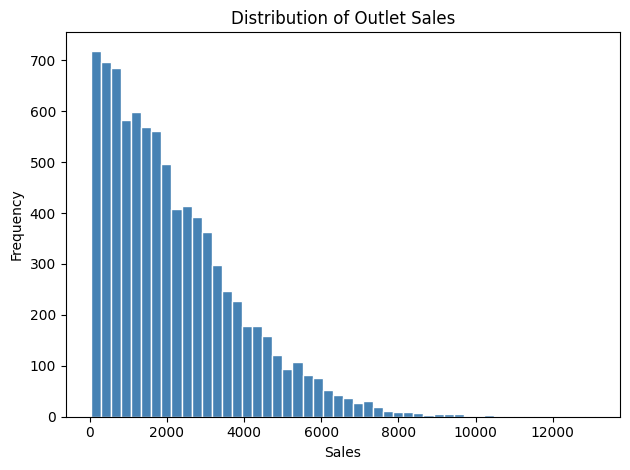

In [100]:
#Distribution of Sales 
plt.Figure(figsize=(8,5))
plt.hist(df['Item_Outlet_Sales'], bins=50, color='steelblue', edgecolor='white')
plt.title('Distribution of Outlet Sales')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

In [101]:
#Average sales per outlet 
outlet_avg_sale = df.groupby('Outlet_Type')['Item_Outlet_Sales'].mean()
outlet_avg_sale

Outlet_Type
Grocery Store         339.828500
Supermarket Type1    2316.181148
Supermarket Type2    1995.498739
Supermarket Type3    3694.038558
Name: Item_Outlet_Sales, dtype: float64

**Task 4: Data Cleaning & Preprocessing**

Real-world data is always messy. We need to clean it before training any model.

- The `Item_Fat_Content` column has inconsistent labels: `'low fat'`, `'LF'` should all be `'Low Fat'`, and `'reg'` should be `'Regular'`.
- Fill missing `Item_Weight` with the **column mean**
- Fill missing `Outlet_Size` with the **column mode**
- Drop `Item_Identifier` and `Outlet_Identifier` — they are just ID columns with no predictive value.
- Use `LabelEncoder` to convert all categorical (object) columns to numerical values.

In [102]:
#To Do 
df['Item_Fat_Content'].value_counts()

Item_Fat_Content
Low Fat    5089
Regular    2889
LF          316
reg         117
low fat     112
Name: count, dtype: int64

In [103]:
df['Item_Fat_Content'] = df['Item_Fat_Content'].replace({
    'low fate':'Low Fat',
    'LF':'Low Fat',
    'reg':'Regular'
})

df['Item_Fat_Content'].value_counts()

Item_Fat_Content
Low Fat    5405
Regular    3006
low fat     112
Name: count, dtype: int64

In [104]:
df.drop(columns=['Item_Identifier'], inplace=True)

In [105]:
df['Outlet_Age']= 2013 -df['Outlet_Establishment_Year']

**Prepare Data for Modeling**

In [106]:
#To Do 
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

In [107]:
le = LabelEncoder()
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    df[col]=le.fit_transform(df[col])
df.dtypes

Item_Weight                  float64
Item_Fat_Content               int64
Item_Visibility              float64
Item_Type                      int64
Item_MRP                     float64
Outlet_Identifier              int64
Outlet_Establishment_Year      int64
Outlet_Size                    int64
Outlet_Location_Type           int64
Outlet_Type                    int64
Item_Outlet_Sales            float64
Outlet_Age                     int64
dtype: object

In [108]:
X = df.drop(columns=['Item_Outlet_Sales'])
y = df['Item_Outlet_Sales']

X.shape, y.shape

((8523, 11), (8523,))

In [109]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


**Task 6: Train All 5 Regression Models**

Now the fun part! We will train 5 different models on the same dataset and compare their performance.

### Models to train:
| # | Model | Key Idea |
|---|-------|----------|
| 1 | **Linear Regression** | Fits a straight line through the data |
| 2 | **K-Nearest Neighbors** | Predicts based on K closest data points |
| 3 | **Decision Tree** | Splits data into branches based on rules |
| 4 | **Random Forest** | Many decision trees voting together (Bagging) |
| 5 | **XGBoost** | Trees that learn from each other's mistakes (Boosting) |

For each model calculate: **RMSE**, **MAE**, and **R² Score**

In [ ]:
#To Do 
models = {
    'Linear Regression': LinearRegression(),
    'K-Nearest Neighbors': KNeighborsRegressor(n_neighbors=5),
    'Decision Tree': DecisionTreeRegressor(max_depth=6, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'XGboost': XGBRegressor(n_estimators =200, learning_rate = 0.05, max_depth = 4, random_state = 42)
}

In [111]:
results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    results.append({'Model':name, "RMSE":round(rmse,2), "R2 Score":round(r2,4)})
    print(f"{name}, RMSE:{rmse:.2f}, R2:{r2:.4f}")

Linear Regression, RMSE:1136.43, R2:0.5248
K-Nearest Neighbors, RMSE:1168.13, R2:0.4980
Decision Tree, RMSE:1043.68, R2:0.5992
Random Forest, RMSE:1081.24, R2:0.5699
XGboost, RMSE:1033.65, R2:0.6069
